In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

import matplotlib
# from matplotlib.image import NonUniformImage
# from scipy.stats import gmean
# imports 
# from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
# from bbhx.waveformbuild import BBHWaveformFD
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13

# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
import math
import pickle


In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("jillian.txt", sep="\t", dtype={"time (Gyr)": float, "mass ratio": float, "redshift": float, "total BH mass (Msun)": float})

In [4]:
time= df['time (Gyr)']
ratio= df['mass ratio']
z=np.array(df['redshift'])
M=df['total BH mass (Msun)']
m1=np.array(M/(1+ratio))
m2=np.array(ratio*m1)
plt.loglog(m1,m2,'o')

In [5]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value/1e3) ## in Gpc

In [6]:
bh=24
parameters = {
    'T': 2 / 52,  # duration in years
    'dt': 10.0,  # timestep in seconds
    'M': 1e6,  # primary mass
    'a': 0.0,  # spin, ignored in Schwarzschild waveform
    'mu': 1e4,  # secondary mass
    'p0': 16,  # initial semi-latus rectum
    'e0': 0,  # initial eccentricity
    'x0': 1.0,  # initial frequency param, ignored in Schwarzschild
    'qK': 0.0,  # polar spin angle
    'phiK': 0,  # azimuthal spin angle
    'qS': 0.3,  # polar sky angle
    'phiS': 0.3,  # azimuthal sky angle
    'dist': 1.0,  # luminosity distance in Gpc
    'Phi_phi0': 0.0,  # initial phase
    'Phi_theta0': 0.0,
    'Phi_r0': 0.0,
    'dt': 10,
}


In [7]:
from lisatools.sources.emri import EMRITDIWaveform
emri_lisa = EMRITDIWaveform(T=1/12., dt=10.,
    response_kwargs=dict(tdi_chan="AET", tdi="1st generation"),
    emri_waveform_kwargs=dict(inspiral_kwargs=dict(integrate_backwards=True)),
)


In [9]:
from lisatools.sensitivity import LISASens, get_sensitivity, get_stock_sensitivity_options

In [10]:
import lisatools.detector as lisa_models

In [11]:
get_stock_sensitivity_options()

['X1TDISens',
 'Y1TDISens',
 'Z1TDISens',
 'XY1TDISens',
 'YZ1TDISens',
 'ZX1TDISens',
 'A1TDISens',
 'E1TDISens',
 'T1TDISens',
 'X2TDISens',
 'Y2TDISens',
 'Z2TDISens',
 'LISASens',
 'CornishLISASens',
 'FlatPSDFunction']

In [12]:
lisa_models.sangria

LISAModel(Soms_d=6.241e-23, Sa_a=5.76e-30, orbits=<lisatools.detector.DefaultOrbits object at 0x73eb12e3e650>, name='sangria')

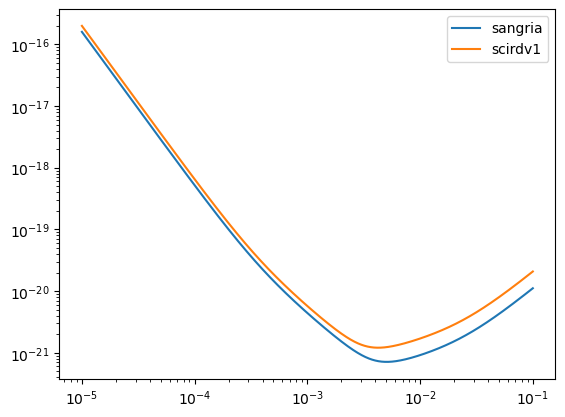

In [ ]:
freq =np.logspace(-5, -1, 1000)
Sn_1 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.sangria, return_type='char_strain')
Sn_2 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.scirdv1, return_type='char_strain')

plt.loglog(freq, Sn_1, label="sangria")
plt.loglog(freq, Sn_2, label="scirdv1")
plt.legend()
plt.show()

In [18]:
Sn_1 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.sangria, return_type='char_strain')

Sn_2 = get_sensitivity(freq, sens_fn=LISASens, average=False, model=lisa_models.sangria, return_type='char_strain')
Sn_1/Sn_2

array([2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 

In [17]:
from lisatools.sensitivity import SensitivityMatrix, LISASens, A1TDISens

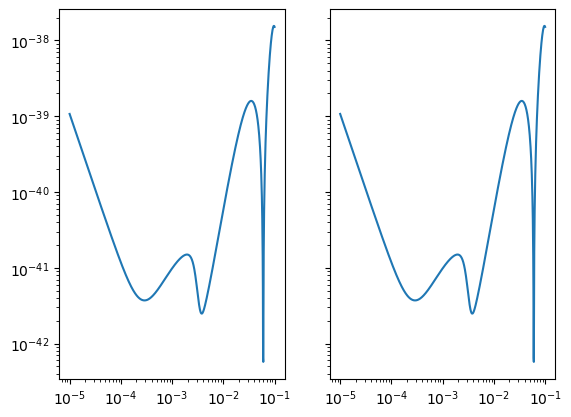

In [18]:
sens_kwargs = dict(
    stochastic_params=(1*YRSID_SI,)
)

sens_mat= SensitivityMatrix(freq,[A1TDISens,A1TDISens], **sens_kwargs)
sens_mat.loglog()
plt.show()

In [19]:
dt=10
Tobs=1*YRSID_SI
Nobs=int(Tobs/dt)
t=np.arange(Nobs)*dt

In [20]:
# clear (for internal clearing of answers)
 
sens_mat_no_confusion = deepcopy(sens_mat)
sens_mat_no_confusion.update_stochastic(stochastic_params=None)

sens_mat_1_yr = deepcopy(sens_mat)
sens_mat_1_yr.update_stochastic(stochastic_params=(1 * YRSID_SI,))

sens_mat_4_yr = deepcopy(sens_mat)
sens_mat_4_yr.update_stochastic(stochastic_params=(4 * YRSID_SI,))

fig, ax = sens_mat_no_confusion.loglog(label="No Stoch")

sens_mat_1_yr.loglog(fig=fig, ax=ax, label="1 yr")
sens_mat_4_yr.loglog(fig=fig, ax=ax, label="4 yr")
ax[0].legend()